# APRENDIZAJE AUTOMÁTICO
# Práctica 3: Regresión Logística Binaria
### Autor: Sanchez Sarsa, Eduardo
### NIP:   901813
### Fecha: 20-02-2026
---


## Configuración


In [1]:
%matplotlib inline
# try:
#   from google.colab import drive
#   print("Trabajando en Colab")
#   drive.mount('/content/drive')                # Monta tu google drive
#   Path = '/content/drive/MyDrive/Aprendizaje/' # Directorio donde guardas los ficheros
# except:
print("Trabajando en local")
import os
Path = os.getcwd() + "/"  # Directorio donde guardas los ficheros


Trabajando en local


---
## 0. Visualización de datos


Train: 142 muestras | positivos=45 (0.317)
Test : 36 muestras | positivos=14 (0.389)


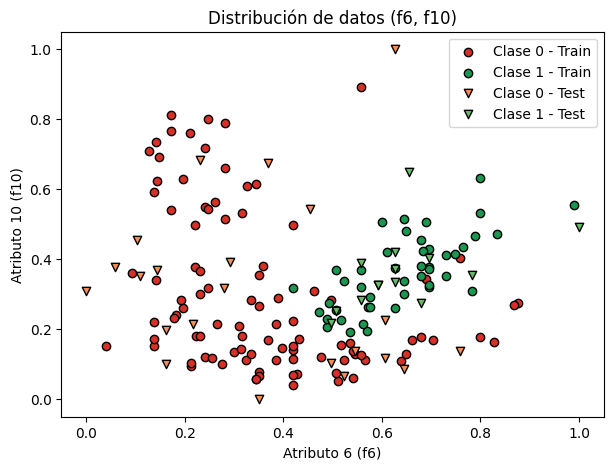

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.exceptions import ConvergenceWarning
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

warnings.filterwarnings("ignore", category=ConvergenceWarning)
SEED = 28


# Dibuja la frontera y los puntos de train/test para clasificadores binarios con 2 atributos.
def dibujar_clasificador(clf, X_train, y_train, X_test, y_test, titulo):
    colores = ListedColormap(["#d73027", "#1a9850"])
    fig, ax = plt.subplots(figsize=(7, 5))
    DecisionBoundaryDisplay.from_estimator(
        clf,
        X_train,
        eps=0.15,
        cmap=colores,
        grid_resolution=400,
        response_method="predict",
        alpha=0.30,
        ax=ax,
    )
    ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c="#d73027", edgecolors="k", label="0 - Train")
    ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c="#1a9850", edgecolors="k", label="1 - Train")
    ax.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], c="#d73027", marker="v", edgecolors="k", label="0 - Test")
    ax.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], c="#1a9850", marker="v", edgecolors="k", label="1 - Test")
    ax.set_xlabel("Atributo 6 (f6)")
    ax.set_ylabel("Atributo 10 (f10)")
    ax.set_title(titulo)
    ax.legend(loc="best")
    plt.show()


# Leer los ficheros de datos y pasarlos a matrices de numpy.
data_train = pd.read_csv(Path + "wine_train.csv", sep=";")
data_test = pd.read_csv(Path + "wine_test.csv", sep=";")

X_train = data_train[["f6", "f10"]].to_numpy()
X_test = data_test[["f6", "f10"]].to_numpy()
y_train = (data_train["Clase"].to_numpy() == 1).astype(int)
y_test = (data_test["Clase"].to_numpy() == 1).astype(int)

print(f"Train: {X_train.shape[0]} muestras | positivos={y_train.sum()} ({y_train.mean():.3f})")
print(f"Test : {X_test.shape[0]} muestras | positivos={y_test.sum()} ({y_test.mean():.3f})")

plt.figure(figsize=(7, 5))
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c="#d73027", edgecolors="k", label="Clase 0 - Train")
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c="#1a9850", edgecolors="k", label="Clase 1 - Train")
plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], c="#fc8d59", marker="v", edgecolors="k", label="Clase 0 - Test")
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], c="#66bd63", marker="v", edgecolors="k", label="Clase 1 - Test")
plt.title("Distribución de datos (f6, f10)")
plt.xlabel("Atributo 6 (f6)")
plt.ylabel("Atributo 10 (f10)")
plt.legend(loc="best")
plt.show()


Los datos están normalizados y hay cierto desbalance de clase (la clase 1 es minoritaria en entrenamiento), por lo que no conviene fijarse solo en `accuracy`. Además, en el plano `(f6, f10)` se aprecia solapamiento entre clases, lo que hace útil comparar un modelo lineal frente a uno no lineal y regularizado.


---
## 1. Métricas

Para este problema de detección de clase 1, son especialmente relevantes:

- `precision`: evita falsos positivos si queremos que las predicciones de clase 1 sean fiables.
- `recall`: mide cuántos vinos de clase 1 conseguimos detectar.
- `F1`: equilibrio entre `precision` y `recall`.
- `average precision (AP)` y curvas `precision/recall`: útiles con clases desbalanceadas y para comparar umbrales.
- `ROC-AUC`: complementa la evaluación basada en ranking de probabilidades.

Se mantiene `accuracy` como referencia, pero no como métrica principal.


In [3]:
def metricas_binarias(y_true, y_pred, y_prob):
    metricas = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    if len(np.unique(y_true)) == 2:
        metricas["roc_auc"] = roc_auc_score(y_true, y_prob)
        metricas["average_precision"] = average_precision_score(y_true, y_prob)
    else:
        metricas["roc_auc"] = np.nan
        metricas["average_precision"] = np.nan

    return metricas


def evaluar_modelo(modelo, nombre, X_train, y_train, X_test, y_test, umbral=None):
    filas = []

    for split, X, y in [("train", X_train, y_train), ("test", X_test, y_test)]:
        y_prob = modelo.predict_proba(X)[:, 1]
        if umbral is None:
            y_pred = modelo.predict(X)
            umbral_usado = np.nan
        else:
            y_pred = (y_prob >= umbral).astype(int)
            umbral_usado = umbral
        m = metricas_binarias(y, y_pred, y_prob)
        tn, fp, fn, tp = confusion_matrix(y, y_pred, labels=[0, 1]).ravel()
        m.update({
            "modelo": nombre,
            "split": split,
            "umbral": umbral_usado,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
        })
        filas.append(m)

    columnas = [
        "modelo", "split", "accuracy", "precision", "recall", "f1",
        "average_precision", "roc_auc", "umbral", "tn", "fp", "fn", "tp"
    ]
    return pd.DataFrame(filas)[columnas]


def dibujar_roc_train_test(modelo, nombre, X_train, y_train, X_test, y_test):
    fig, ax = plt.subplots(figsize=(7, 5))

    for split, X, y in [("train", X_train, y_train), ("test", X_test, y_test)]:
        y_prob = modelo.predict_proba(X)[:, 1]
        fpr, tpr, _ = roc_curve(y, y_prob)
        auc = roc_auc_score(y, y_prob)
        ax.plot(fpr, tpr, linewidth=2, label=f"{split} | AUC={auc:.3f}")

    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Tasa de Falsos Positivos")
    ax.set_ylabel("Tasa de Verdaderos Positivos")
    ax.set_title(f"ROC - {nombre}")
    ax.grid(alpha=0.25)
    ax.legend(loc="lower right")
    plt.show()


print("Métrica principal para selección: average_precision (AP)")
print(f"Prevalencia de clase 1 en train: {y_train.mean():.3f}")
print(f"Prevalencia de clase 1 en test : {y_test.mean():.3f}")


Métrica principal para selección: average_precision (AP)
Prevalencia de clase 1 en train: 0.317
Prevalencia de clase 1 en test : 0.389


---
## 2. Regresión logística básica
### a) Entrenamiento, superficie de separación y evaluación


c:\Users\eduar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


,modelo,split,accuracy,precision,recall,f1,average_precision,roc_auc,umbral,tn,fp,fn,tp
0,Logística básica,train,0.809859,0.736842,0.622222,0.674699,0.744974,0.906987,NaN,87,10,17,28
1,Logística básica,test,0.861111,0.846154,0.785714,0.814815,0.771994,0.883117,NaN,20,2,3,11


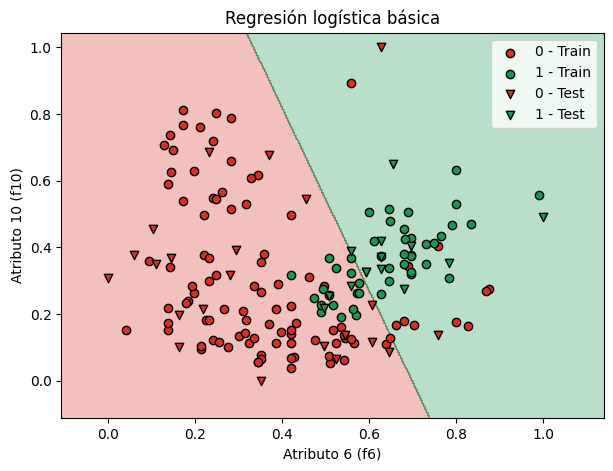

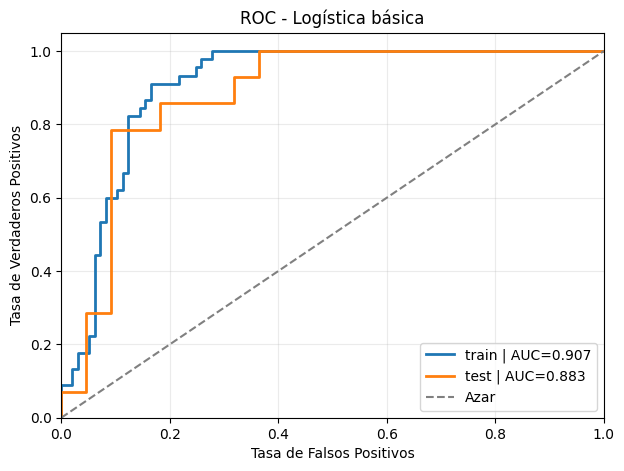

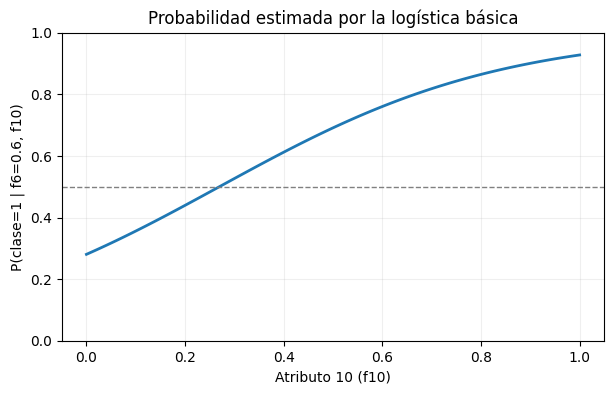

Coeficientes: w_f6=9.5750, w_f10=3.4955, b=-6.6871
Para f6=0.6, el punto con P=0.5 ocurre en f10≈0.2695


In [4]:
logit_basico = LogisticRegression(l1_ratio=0, C=np.inf)
logit_basico.fit(X_train, y_train)

metricas_basico = evaluar_modelo(
    logit_basico,
    "Logística básica",
    X_train,
    y_train,
    X_test,
    y_test
)

display(metricas_basico)
dibujar_clasificador(logit_basico, X_train, y_train, X_test, y_test, "Regresión logística básica")

dibujar_roc_train_test(logit_basico, "Logística básica", X_train, y_train, X_test, y_test)


# Probabilidad para f6=0.6 y f10 entre 0 y 1.
f10_grid = np.linspace(0.0, 1.0, 100)
X_consulta = np.c_[np.full_like(f10_grid, 0.6), f10_grid]
prob_clase1 = logit_basico.predict_proba(X_consulta)[:, 1]

plt.figure(figsize=(7, 4))
plt.plot(f10_grid, prob_clase1, color="#1f78b4", linewidth=2)
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Atributo 10 (f10)")
plt.ylabel("P(clase=1 | f6=0.6, f10)")
plt.title("Probabilidad estimada por la logística básica")
plt.ylim(0, 1)
plt.grid(alpha=0.2)
plt.show()

w_f6, w_f10 = logit_basico.coef_[0]
b = logit_basico.intercept_[0]
print(f"Coeficientes: w_f6={w_f6:.4f}, w_f10={w_f10:.4f}, b={b:.4f}")

if abs(w_f10) > 1e-12:
    f10_corte = -(b + w_f6 * 0.6) / w_f10
    print(f"Para f6=0.6, el punto con P=0.5 ocurre en f10≈{f10_corte:.4f}")
else:
    print("w_f10≈0: la probabilidad casi no depende de f10")


### Interpretación

La gráfica de probabilidad en función de `f10` (con `f6` fijo) tiene forma sigmoide. La razón es que la regresión logística aplica la función logística a un predictor lineal:

`P(y=1|x) = sigma(w0 + w1*f6 + w2*f10)`.

Al fijar `f6=0.6`, la expresión interna queda lineal en `f10`; al pasarla por `sigma`, aparece la curva en S.


### Interpretación

La gráfica de probabilidad en función de `f10` (con `f6` fijo) tiene forma sigmoide. La razón es que la regresión logística aplica la función logística a un predictor lineal:

`P(y=1|x) = sigma(w0 + w1*f6 + w2*f10)`.

Al fijar `f6=0.6`, la expresión interna queda lineal en `f10`; al pasarla por `sigma`, aparece la curva en S.


---
## 3. Expansión polinómica (grado 6) sin regularizar


,solver,ap_train_media,ap_val_media,ap_val_std,f1_train,f1_val
1,newton-cg,1.000000,0.850924,0.113730,1.000000,0.884474
3,sag,0.957721,0.936958,0.052615,0.929059,0.877807
2,saga,0.956690,0.932685,0.055794,0.923129,0.877807
0,lbfgs,0.996730,0.871192,0.117703,0.980670,0.859138
4,newton-cholesky,0.996845,0.871605,0.117651,0.980820,0.859138


Modelos sin regularización guardados para 5b: 5
Solver seleccionado para el modelo sin regularizar: newton-cg (CV F1=0.8845)


c:\Users\eduar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_glm\_newton_solver.py:591: LinAlgWarning: The inner solver of NewtonCholeskySolver stumbled upon a singular or very ill-conditioned Hessian matrix at iteration 1. It will now resort to lbfgs instead.
Further options are to use another solver or to avoid such situation in the first place. Possible remedies are removing collinear features of X or increasing the penalization strengths.
The original Linear Algebra message was:
Ill-conditioned matrix (rcond=4.11357e-25): result may not be accurate.
  warnings.warn(


,modelo,split,accuracy,precision,recall,f1,average_precision,roc_auc,umbral,tn,fp,fn,tp
0,Polinómica g6 sin regularizar (newton-cg),train,1.000000,1.0000,1.000000,1.000000,1.000000,1.000000,NaN,97,0,0,45
1,Polinómica g6 sin regularizar (newton-cg),test,0.888889,0.8125,0.928571,0.866667,0.811936,0.922078,NaN,19,3,1,13


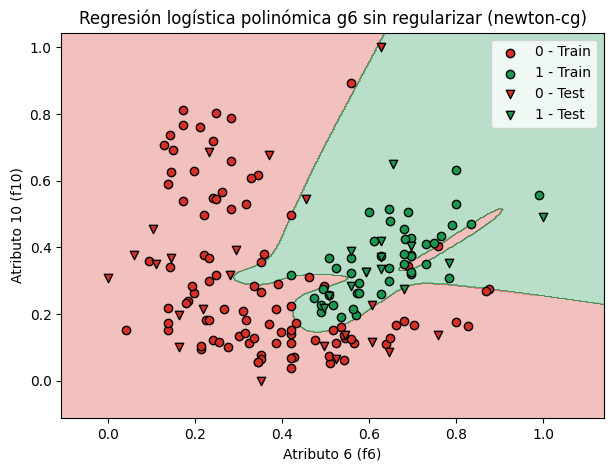

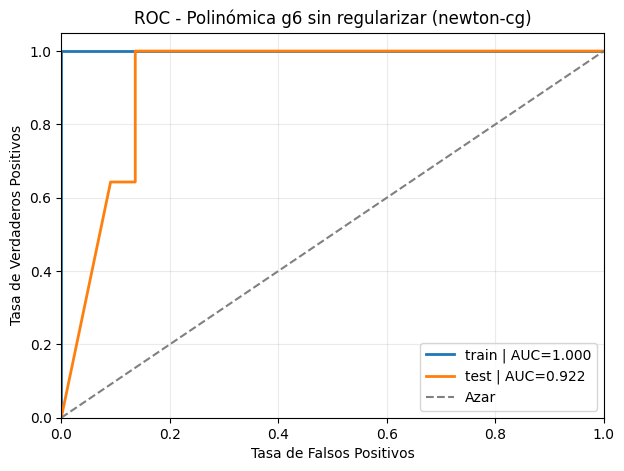

In [ ]:
solvers_sin_reg = ["lbfgs", "newton-cg", "saga", "sag", "newton-cholesky"]  # "liblinear" no soporta penalty=None

warnings.filterwarnings("ignore", category=UserWarning, message="Setting penalty=None")

grid_sin_reg = GridSearchCV(
    estimator=Pipeline(
        [
            ("poly", PolynomialFeatures(degree=6)),
            ("logreg", LogisticRegression(l1_ratio=0, C=np.inf, max_iter=2000, tol=1e-8)),
        ]
    ),
    param_grid={"logreg__solver": solvers_sin_reg},
    scoring={"ap": "average_precision", "f1": "f1"},
    refit="f1",
    return_train_score=True,
    error_score=np.nan,
    n_jobs=-1,
)

grid_sin_reg.fit(X_train, y_train)

cv_results_sin_reg = grid_sin_reg.cv_results_
df_sin_reg = pd.DataFrame(
    {
        "solver": np.array(cv_results_sin_reg["param_logreg__solver"], dtype=str),
        "ap_train_media": cv_results_sin_reg["mean_train_ap"],
        "ap_val_media": cv_results_sin_reg["mean_test_ap"],
        "ap_val_std": cv_results_sin_reg["std_test_ap"],
        "f1_train": cv_results_sin_reg["mean_train_f1"],
        "f1_val": cv_results_sin_reg["mean_test_f1"],
    }
).sort_values(by="f1_val", ascending=False)

df_sin_reg = df_sin_reg.dropna(subset=["f1_val"])
if df_sin_reg.empty:
    raise RuntimeError("No se pudo entrenar ningún modelo polinómico sin regularizar")

display(df_sin_reg)

# Guardamos un modelo reentrenado por solver para reutilizarlo en el apartado 5b.
modelos_poly_sin_reg_por_solver = {}
for solver in df_sin_reg["solver"].tolist():
    try:
        modelo_solver = Pipeline(
            [
                ("poly", PolynomialFeatures(degree=6)),
                ("logreg", LogisticRegression(l1_ratio=0, C=np.inf, max_iter=2000, tol=1e-8, solver=solver)),
            ]
        )
        modelo_solver.fit(X_train, y_train)
        modelos_poly_sin_reg_por_solver[f"Polinómica g6 sin reg ({solver})"] = modelo_solver
    except Exception as e:
        warnings.warn(f"No se pudo reentrenar el solver sin regularizar {solver}: {e}")

print(f"Modelos sin regularización guardados para 5b: {len(modelos_poly_sin_reg_por_solver)}")

mejor_solver_sin_reg = grid_sin_reg.best_params_["logreg__solver"]
modelo_poly_sin_reg = grid_sin_reg.best_estimator_

print(
    f"Solver seleccionado para el modelo sin regularizar: {mejor_solver_sin_reg} "
    f"(CV F1={grid_sin_reg.best_score_:.4f})"
)

metricas_sin_reg = evaluar_modelo(
    modelo_poly_sin_reg,
    f"Polinómica g6 sin regularizar ({mejor_solver_sin_reg})",
    X_train,
    y_train,
    X_test,
    y_test
)
display(metricas_sin_reg)

dibujar_clasificador(
    modelo_poly_sin_reg,
    X_train,
    y_train,
    X_test,
    y_test,
    f"Regresión logística polinómica g6 sin regularizar ({mejor_solver_sin_reg})",
)

dibujar_roc_train_test(
    modelo_poly_sin_reg,
    f"Polinómica g6 sin regularizar ({mejor_solver_sin_reg})",
    X_train,
    y_train,
    X_test,
    y_test,
)


---
## 4. Regularización (grado 6) y selección de `C` con k-fold

Se usa validación cruzada estratificada (`k=5`) y métrica de selección `f1`.


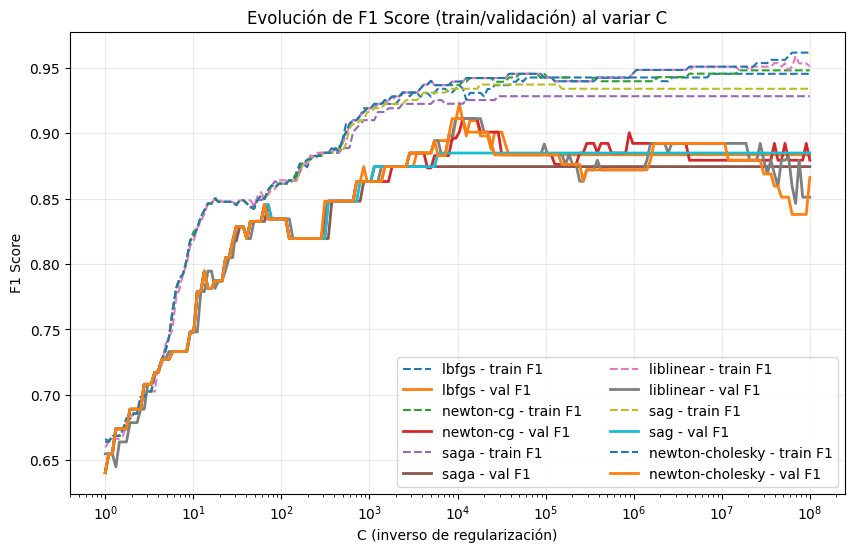

,solver,C,train_f1,val_f1,val_f1_std
0,lbfgs,10473.708980,0.936852,0.922863,0.041073
1,liblinear,9547.716114,0.939583,0.911196,0.044577
2,newton-cg,11489.510002,0.939583,0.911196,0.044577
3,newton-cholesky,8703.591361,0.939583,0.911196,0.044577
4,sag,6010.276782,0.931163,0.884903,0.035922
5,saga,1135.733358,0.910013,0.874513,0.034923


Modelos regularizados guardados para 5b: 6
Mejor combinación por CV: solver=lbfgs, C=10473.7, val_F1=0.9229


,modelo,split,accuracy,precision,recall,f1,average_precision,roc_auc,umbral,tn,fp,fn,tp
0,"Polinómica g6 regularizada (lbfgs, C=1.047e+04)",train,0.957746,0.914894,0.955556,0.934783,0.967481,0.986712,NaN,93,4,2,43
1,"Polinómica g6 regularizada (lbfgs, C=1.047e+04)",test,0.944444,0.928571,0.928571,0.928571,0.984642,0.990260,NaN,21,1,1,13


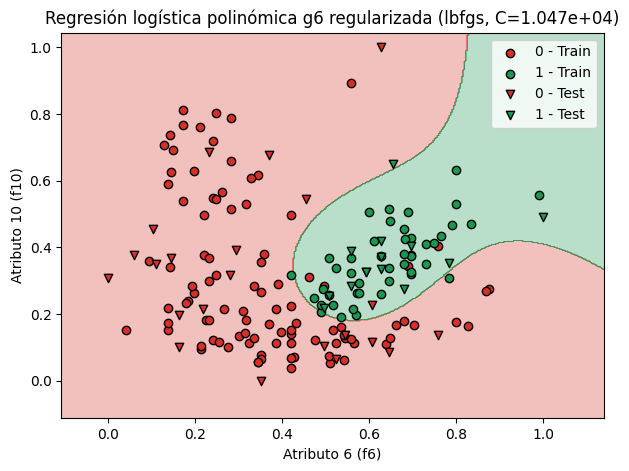

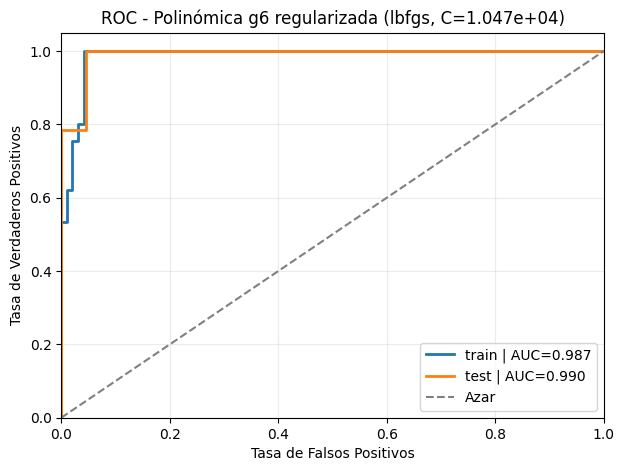

In [6]:
Cs = np.logspace(0, 8, 200)
solvers_reg = ["lbfgs", "newton-cg", "saga", "liblinear", "sag", "newton-cholesky"]
cv = KFold(n_splits=5, shuffle=True, random_state=28)

grid_reg = GridSearchCV(
    estimator=Pipeline(
        [
            ("poly", PolynomialFeatures(degree=6, include_bias=False)),
            ("logreg", LogisticRegression(max_iter=5000, random_state=28)),
        ]
    ),
    param_grid={"logreg__solver": solvers_reg, "logreg__C": Cs},
    scoring="f1",
    cv=cv,
    return_train_score=True,
    error_score=np.nan,
    n_jobs=-1,
)

grid_reg.fit(X_train, y_train)

cv_results = grid_reg.cv_results_
df_cv = pd.DataFrame(
    {
        "solver": np.array(cv_results["param_logreg__solver"], dtype=str),
        "C": np.array(cv_results["param_logreg__C"], dtype=float),
        "train_f1": cv_results["mean_train_score"],
        "val_f1": cv_results["mean_test_score"],
        "val_f1_std": cv_results["std_test_score"],
    }
)

df_cv_ok = df_cv.dropna(subset=["val_f1"]).copy()
if df_cv_ok.empty:
    raise RuntimeError("No se pudo completar la validación cruzada para ningún solver")

plt.figure(figsize=(10, 6))
for solver in solvers_reg:
    d = df_cv_ok[df_cv_ok["solver"] == solver].sort_values("C")
    if d.empty:
        continue
    plt.semilogx(d["C"], d["train_f1"], linestyle="--", linewidth=1.5, label=f"{solver} - train F1")
    plt.semilogx(d["C"], d["val_f1"], linestyle="-", linewidth=2.0, label=f"{solver} - val F1")

plt.xlabel("C (inverso de regularización)")
plt.ylabel("F1 Score")
plt.title("Evolución de F1 Score (train/validación) al variar C")
plt.grid(alpha=0.25)
plt.legend(loc="best", ncol=2)
plt.show()

# Mejor C por solver para conservar una versión de cada uno (?til en 5b).
df_mejores_reg_por_solver = (
    df_cv_ok.sort_values(["solver", "val_f1", "C"], ascending=[True, False, True])
    .groupby("solver", as_index=False)
    .first()[["solver", "C", "train_f1", "val_f1", "val_f1_std"]]
    .sort_values("val_f1", ascending=False)
    .reset_index(drop=True)
)
display(df_mejores_reg_por_solver)

modelos_poly_reg_por_solver = {}
mejores_C_reg_por_solver = {}
for _, fila in df_mejores_reg_por_solver.iterrows():
    solver = str(fila["solver"])
    C_solver = float(fila["C"])
    mejores_C_reg_por_solver[solver] = C_solver

    modelo_solver = Pipeline(
        [
            ("poly", PolynomialFeatures(degree=6, include_bias=False)),
            ("logreg", LogisticRegression(solver=solver, C=C_solver, max_iter=5000, random_state=28)),
        ]
    )
    modelo_solver.fit(X_train, y_train)
    modelos_poly_reg_por_solver[f"Polinómica g6 reg ({solver}, C={C_solver:.3g})"] = modelo_solver

print(f"Modelos regularizados guardados para 5b: {len(modelos_poly_reg_por_solver)}")

mejor_solver_reg = grid_reg.best_params_["logreg__solver"]
mejor_C = float(grid_reg.best_params_["logreg__C"])

print(f"Mejor combinación por CV: solver={mejor_solver_reg}, C={mejor_C:.6g}, val_F1={grid_reg.best_score_:.4f}")

# GridSearchCV ya reentrena con la mejor combinación usando todo el train.
modelo_poly_reg = grid_reg.best_estimator_

metricas_reg = evaluar_modelo(
    modelo_poly_reg,
    f"Polinómica g6 regularizada ({mejor_solver_reg}, C={mejor_C:.4g})",
    X_train,
    y_train,
    X_test,
    y_test
)
display(metricas_reg)

dibujar_clasificador(
    modelo_poly_reg,
    X_train,
    y_train,
    X_test,
    y_test,
    f"Regresión logística polinómica g6 regularizada ({mejor_solver_reg}, C={mejor_C:.4g})",
)

dibujar_roc_train_test(
    modelo_poly_reg,
    f"Polinómica g6 regularizada ({mejor_solver_reg}, C={mejor_C:.4g})",
    X_train,
    y_train,
    X_test,
    y_test,
)


---
## 5. Curvas Precisión/Recall y ROC
### a) Comparación en test


Modelos disponibles para 5b: 12


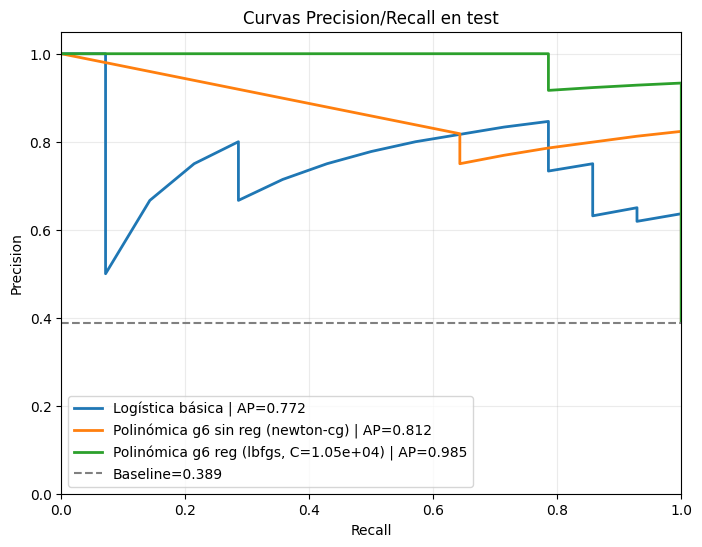

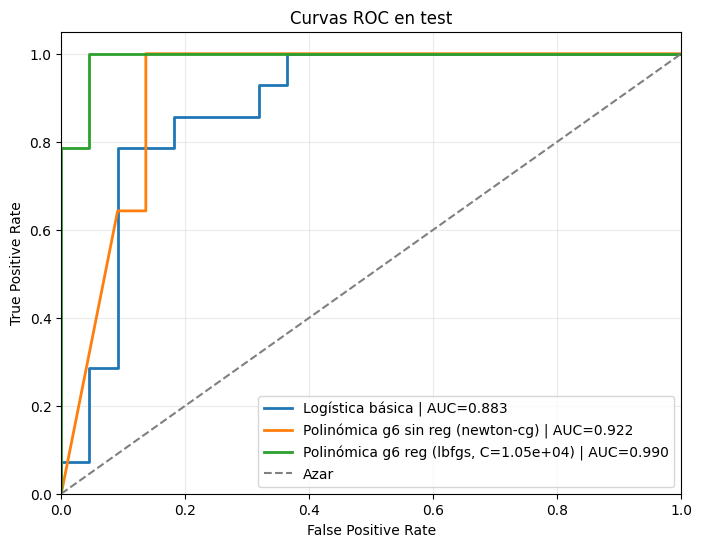

In [7]:
modelos_principales = {
    "Logística básica": logit_basico,
    f"Polinómica g6 sin reg ({mejor_solver_sin_reg})": modelo_poly_sin_reg,
    f"Polinómica g6 reg ({mejor_solver_reg}, C={mejor_C:.3g})": modelo_poly_reg,
}

# Para 5b usamos TODOS los modelos guardados (principales + variantes por solver).
modelos = dict(modelos_principales)
modelos.update(modelos_poly_sin_reg_por_solver)
modelos.update(modelos_poly_reg_por_solver)
print(f"Modelos disponibles para 5b: {len(modelos)}")

probs_test = {nombre: modelo.predict_proba(X_test)[:, 1] for nombre, modelo in modelos_principales.items()}

# Curvas Precision/Recall en una figura conjunta.
plt.figure(figsize=(8, 6))
for nombre, prob in probs_test.items():
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    plt.plot(recall, precision, linewidth=2, label=f"{nombre} | AP={ap:.3f}")

baseline = y_test.mean()
plt.hlines(baseline, 0, 1, colors="gray", linestyles="--", label=f"Baseline={baseline:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curvas Precision/Recall en test")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.grid(alpha=0.25)
plt.legend(loc="best")
plt.show()


# Curvas ROC en una figura conjunta (todos los modelos principales).
fig, ax = plt.subplots(figsize=(8, 6))
for nombre, prob in probs_test.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, linewidth=2, label=f"{nombre} | AUC={auc:.3f}")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Curvas ROC en test")
ax.grid(alpha=0.25)
ax.legend(loc="lower right")
plt.show()


In [ ]:
# b) Ajuste de umbral con TunedThresholdClassifierCV para garantizar precision >= 0.90.
# Nota: aquí usamos cv="prefit" para reutilizar los modelos ya ajustados. Si se calibra con test,
# la evaluación sobre ese mismo test queda optimista (sirve para comparación rápida entre modelos).
from sklearn.metrics import make_scorer
from sklearn.model_selection import TunedThresholdClassifierCV



# Para poder usar TunedThresholdClassifierCV, convierto ese criterio en un "score":
# - si no cumple la precision minima, devuelvo un valor muy malo (-1)
# - si si cumple, devuelvo el recall (asi el tuner maximiza recall)
def recall_si_precision_minima(y_true, y_pred, precision_minima=0.90):
    precision = precision_score(y_true, y_pred, zero_division=0)
    if precision < precision_minima:
        return -1.0
    return recall_score(y_true, y_pred, zero_division=0)


precision_objetivo = 0.90
scorer_umbral = make_scorer(recall_si_precision_minima, precision_minima=precision_objetivo)
registros_umbral = []

for nombre, modelo in modelos.items():
    prob_test = modelo.predict_proba(X_test)[:, 1]
    thresholds = np.unique(prob_test)

    tuner = TunedThresholdClassifierCV(
        estimator=modelo,
        scoring=scorer_umbral,
        response_method="predict_proba",
        thresholds=thresholds,
        # Le ponemos que ya está entrenado.
        cv="prefit",
        refit=False,
    )
    # Entrenamos con datos de train.
    tuner.fit(X_train, y_train)

    y_pred = tuner.predict(X_test)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

    registros_umbral.append(
        {
            "modelo": nombre,
            "factible": bool(precision >= precision_objetivo),
            "threshold": float(tuner.best_threshold_),
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
            "predichos_clase1": int(y_pred.sum()),
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
        }
    )


df_umbral = pd.DataFrame(registros_umbral).sort_values(
    by=["factible", "recall", "precision"],
    ascending=[False, False, False],
)
display(df_umbral)


,modelo,factible,threshold,precision,recall,f1,predichos_clase1,tn,fp,fn,tp
2,"Polinómica g6 reg (lbfgs, C=1.05e+04)",True,0.346391,0.933333,1.000000,0.965517,15,21,1,0,14
10,"Polinómica g6 reg (sag, C=6.01e+03)",True,0.296254,0.933333,1.000000,0.965517,15,21,1,0,14
3,Polinómica g6 sin reg (sag),True,0.394317,0.928571,0.928571,0.928571,14,21,1,1,13
4,Polinómica g6 sin reg (saga),True,0.249919,0.928571,0.928571,0.928571,14,21,1,1,13
11,"Polinómica g6 reg (saga, C=1.14e+03)",True,0.489582,0.928571,0.928571,0.928571,14,21,1,1,13
1,Polinómica g6 sin reg (newton-cg),False,0.665227,0.875000,1.000000,0.933333,16,20,2,0,14
5,Polinómica g6 sin reg (lbfgs),False,0.624285,0.875000,1.000000,0.933333,16,20,2,0,14
6,Polinómica g6 sin reg (newton-cholesky),False,0.624285,0.875000,1.000000,0.933333,16,20,2,0,14
7,"Polinómica g6 reg (liblinear, C=9.55e+03)",False,0.632527,0.875000,1.000000,0.933333,16,20,2,0,14
8,"Polinómica g6 reg (newton-cg, C=1.15e+04)",False,0.643322,0.875000,1.000000,0.933333,16,20,2,0,14
